In [1]:
# Install required visualization libraries
!pip install -q gdown networkx matplotlib

# Clone GSDiff repository
!git clone https://github.com/SizheHu/GSDiff.git
%cd GSDiff

# Create outputs directory
!mkdir -p outputs
%cd outputs

# Download topology-constrained params
!gdown "1pk7SmvLZ8ON3OUL3SNxPRu73ndVKru0z"

# Download topology-autoencoder Transformer params
!gdown "1tExX8LdrFpJfBQH5y2emC6BltBwf9tHx"

# Extract and cleanup
!tar -xvf *.tar*
!unzip -q topo-params.zip
%cd /content/GSDiff

Cloning into 'GSDiff'...
remote: Enumerating objects: 521, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 521 (delta 63), reused 18 (delta 18), pack-reused 417 (from 2)
Receiving objects: 100% (521/521), 911.27 KiB | 12.48 MiB/s, done.
Resolving deltas: 100% (320/320), done.
/content/GSDiff
/content/GSDiff/outputs
Downloading...
From (original): https://drive.google.com/uc?id=1pk7SmvLZ8ON3OUL3SNxPRu73ndVKru0z
From (redirected): https://drive.google.com/uc?id=1pk7SmvLZ8ON3OUL3SNxPRu73ndVKru0z&confirm=t&uuid=8623a6d2-235d-4d0f-bc22-8a4eb09a3d58
To: /content/GSDiff/outputs/topo-params.zip
100% 513M/513M [00:08<00:00, 59.8MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=1tExX8LdrFpJfBQH5y2emC6BltBwf9tHx
From (redirected): https://drive.google.com/uc?id=1tExX8LdrFpJfBQH5y2emC6BltBwf9tHx&confirm=t&uuid=5b40a0ab-c78e-449e-a76a-596ea8b100c8
To: /content/GSDiff/outputs/topoae.tar
100% 154M/154M [00:03<00:

In [2]:
!pip install -q pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 3.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.7 MB/s eta 0:00:0000:01


In [3]:
user_input = {
    "property_type": "apartment",
    "rooms": {
        "living_rooms": 1,    # <--- NEW: 1 Main Hub, 1 Secondary
        "bedrooms": 2, 
        "master_bedrooms": 1, 
        "bathrooms": 2,       
        "kitchens": 1,
        "storage": 0
    }
}

In [4]:
import random
import numpy as np

def generate_topology_from_form(user_input):
    """
    Generates topology with a Living Room Chain (Public to Private transition).
    Room IDs: 0: Living, 1: Bedroom, 2: Storage, 3: Kitchen, 4: Bathroom
    """
    rng = random.SystemRandom() 
    rooms_req = user_input.get("rooms", {})
    nodes = []
    edges = []
    
    def add_node(room_type):
        nodes.append(room_type)
        return len(nodes) - 1

    # ==========================================
    # 1. THE LIVING ROOM CHAIN
    # ==========================================
    num_living = max(1, rooms_req.get("living_rooms", 1))
    living_indices = []
    
    # Create all living room nodes
    for _ in range(num_living):
        living_indices.append(add_node(0))
        
    # Link them together in a chain (L0 -> L1 -> L2...)
    if num_living > 1:
        for i in range(num_living - 1):
            edges.append([living_indices[i], living_indices[i+1]])

    # Define the ends of the chain
    public_hub = living_indices[0]        # Connects to Kitchens/Public
    private_hub = living_indices[-1]      # Connects to Beds/Private

    # ==========================================
    # 2. PUBLIC WING (Connected to Public Hub)
    # ==========================================
    kitchen_indices = []
    for _ in range(rooms_req.get("kitchens", 0)):
        k_idx = add_node(3)
        edges.append([public_hub, k_idx])
        kitchen_indices.append(k_idx)

    num_baths = rooms_req.get("bathrooms", 0)
    private_bath_count = 0
    if num_baths > 0:
        # Bath 1 is Public (Wet Wall)
        public_bath_idx = add_node(4)
        edges.append([public_hub, public_bath_idx])
        if kitchen_indices:
            edges.append([kitchen_indices[0], public_bath_idx])
        private_bath_count = num_baths - 1

    # ==========================================
    # 3. PRIVATE WING (Connected to Private Hub)
    # ==========================================
    num_beds = rooms_req.get("bedrooms", 0)
    bed_indices = []
    for _ in range(num_beds):
        b_idx = add_node(1)
        edges.append([private_hub, b_idx]) 
        bed_indices.append(b_idx)

    # Spanning Tree Cluster
    if num_beds > 1:
        for i in range(1, num_beds):
            target_bed = rng.choice(bed_indices[:i])
            edges.append([bed_indices[i], target_bed])

    # ==========================================
    # 4. MASTER SUITES & HALL BATHROOMS
    # ==========================================
    num_masters_requested = rooms_req.get("master_bedrooms", 0)
    
    if private_bath_count > 0:
        actual_masters = min(private_bath_count, num_masters_requested, num_beds)
        hall_baths = private_bath_count - actual_masters
        
        shuffled_beds = bed_indices.copy()
        rng.shuffle(shuffled_beds)
        
        master_beds = shuffled_beds[:actual_masters]
        secondary_beds = shuffled_beds[actual_masters:]
        
        # A. Assign Master En-suites (Connects ONLY to exactly 1 bedroom)
        for m_bed in master_beds:
            en_suite_idx = add_node(4)
            edges.append([m_bed, en_suite_idx])
            
        # B. Assign Hall Baths (Accessible from the PRIVATE Hub)
        for _ in range(hall_baths):
            hall_bath_idx = add_node(4)
            edges.append([private_hub, hall_bath_idx])
            if secondary_beds:
                edges.append([rng.choice(secondary_beds), hall_bath_idx])
            elif master_beds:
                edges.append([rng.choice(master_beds), hall_bath_idx])

    # ==========================================
    # 5. STORAGE
    # ==========================================
    for _ in range(rooms_req.get("storage", 0)):
        stor_idx = add_node(2)
        edges.append([public_hub, stor_idx]) # Usually near entrance/public

    return nodes, edges

In [5]:
from pyvis.network import Network 
import IPython
import networkx as nx
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
def visualize_agent_output(nodes, edges):
    room_mapping = {0: "Living", 1: "Bedroom", 2: "Storage", 3: "Kitchen", 4: "Bathroom", 5: "Balcony"}
    color_map = {0: '#F4F1DE', 1: '#EAB69F', 2: '#6B705C', 3: '#E07A5F', 4: '#5F797B', 5: '#F2CC8F'}

    G = nx.Graph()
    node_colors = []
    labels = {}

    for i, room_type in enumerate(nodes):
        G.add_node(i)
        node_colors.append(color_map.get(room_type, '#CCCCCC'))
        labels[i] = f"[{i}]\n{room_mapping.get(room_type, 'Unknown')}"

    for u, v in edges:
        G.add_edge(u, v)

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, k=0.9, iterations=50) 
    nx.draw(G, pos, with_labels=True, labels=labels, node_color=node_colors, 
            node_size=3000, font_size=9, font_weight="bold", edge_color="#555555", width=2.5)
    plt.title("AI Generated Topology (Bubble Diagram)", fontsize=14, fontweight="bold")
    plt.show()

# nodes ,edges= generate_topology_from_form(user_input)

# visualize_agent_output(nodes,edges)

--- GENERATING DYNAMIC TOPOLOGY ---
Generated Nodes: [0, 3, 4, 1, 1, 4]
Generated Edges: [[0, 1], [0, 2], [1, 2], [0, 3], [0, 4], [4, 3], [3, 5]]


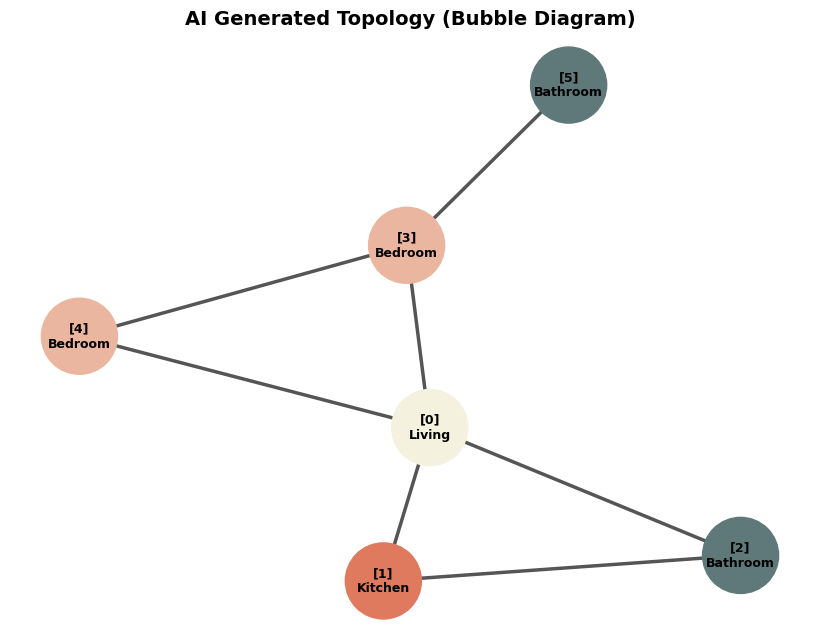

--------------------------------------

Graph embedding network loaded and frozen.
Edge post-processing network loaded and frozen.
Diffusion model loaded and frozen. Starting generation...



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1787: UserWarning: input's size at dim=1 does not match num_features. You can silence this warning by not passing in num_features, which is not used because affine=False
  return forward_call(*args, **kwargs)
Diffusion Process:   3%|▎         | 28/1000 [01:15<43:32,  2.69s/it]


KeyboardInterrupt: 

In [6]:
import sys
import os
import cv2
from PIL import Image, ImageDraw
import math
import torch
import shutil
import random
import numpy as np
import networkx as nx
from tqdm import tqdm
import torch.nn.functional as F
import json

# 1. Modify Paths for Colab
sys.path.append('/content/GSDiff')
sys.path.append('/content/GSDiff/datasets')
sys.path.append('/content/GSDiff/gsdiff')
sys.path.append('/content/GSDiff/scripts/metrics')

from gsdiff.heterhouse_80_106_2 import TopoHeterHouseModel
from gsdiff.bubble_diagram_57_9 import TopoGraphModel
from gsdiff.heterhouse_56_31 import TopoEdgeModel
from gsdiff.utils import *

diffusion_steps = 1000
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
merge_points = True
align_points = True
aa_scale = 1
resolution = 512
num_custom_samples = 15 # Bumping this up to 15

'''create output_dir'''
output_dir = 'outputs/custom_test/'
json_dir = 'outputs/custom_jsons/'
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=False)

# Clean up and recreate JSON output directory
if os.path.exists(json_dir):
    shutil.rmtree(json_dir)
os.makedirs(json_dir, exist_ok=True) 

colors = {6: (0, 0, 0), 0: (244, 241, 222), 1: (234, 182, 159), 2: (107, 112, 92), 3: (224, 122, 95), 4: (95, 121, 123), 5: (242, 204, 143)}

'''Diffusion Settings'''
alpha_bar = lambda t: math.cos((t) / 1.000 * math.pi / 2) ** 2
betas = []
max_beta = 0.999
for i in range(diffusion_steps):
    t1 = i / diffusion_steps
    t2 = (i + 1) / diffusion_steps
    betas.append(min(1 - alpha_bar(t2) / alpha_bar(t1), max_beta))
betas = np.array(betas, dtype=np.float64)
alphas = 1.0 - betas
alphas_cumprod = np.cumprod(alphas)
alphas_cumprod_prev = np.append(1.0, alphas_cumprod[:-1])
sqrt_recip_alphas_cumprod = np.sqrt(1.0 / alphas_cumprod)
sqrt_recipm1_alphas_cumprod = np.sqrt(1.0 / alphas_cumprod - 1)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
posterior_mean_coef1 = betas * np.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod)
posterior_mean_coef2 = (1.0 - alphas_cumprod_prev) * np.sqrt(alphas) / (1.0 - alphas_cumprod)

# ==============================================================================
# --- PROCEDURAL GRAPH GENERATOR (REPLACES AI AGENT) ---
# ==============================================================================

def generate_tensors_from_agent(room_list, edges_list, num_custom_samples=15):
    """ Converts nodes/edges into GSDiff PyTorch tensors. """
    num_rooms = len(room_list)
    
    # 1. Build Semantics Tensor (N x 7)
    semantics = np.zeros((num_rooms, 7), dtype=np.float64)
    for i, room_idx in enumerate(room_list):
        semantics[i, room_idx] = 1.0
    bb_semantics = torch.tensor(semantics, dtype=torch.float32).unsqueeze(0).repeat(num_custom_samples, 1, 1)

    # 2. Build Adjacency Matrix (N x N)
    adjacency = np.zeros((num_rooms, num_rooms), dtype=np.uint8)
    for u, v in edges_list:
        adjacency[u, v] = adjacency[v, u] = 1
    bb_adjacency = torch.tensor(adjacency, dtype=torch.float32).unsqueeze(0).repeat(num_custom_samples, 1, 1)

    # 3. Build Masks
    semantics_mask = np.ones((num_rooms, 1), dtype=np.uint8)
    bb_semantics_padding_mask = torch.tensor(semantics_mask, dtype=torch.float32).unsqueeze(0).repeat(num_custom_samples, 1, 1)

    global_matrix = np.ones((num_rooms, num_rooms), dtype=np.uint8)
    bb_global_matrix = torch.tensor(global_matrix, dtype=torch.float32).unsqueeze(0).repeat(num_custom_samples, 1, 1)

    # 4. Room Number Encoding
    room_number = np.zeros((1, 6), dtype=np.uint8)
    room_idx = max(0, min(num_rooms - 4, 5)) 
    room_number[0, room_idx] = 1
    bb_room_number = torch.tensor(room_number, dtype=torch.float32).unsqueeze(0).repeat(num_custom_samples, 1, 1)

    # 5. Standard padding/attention tensors
    corners_withsemantics_0 = torch.zeros((num_custom_samples, 53, 9), dtype=torch.float32)
    global_attn_matrix = torch.ones((num_custom_samples, 53, 53), dtype=torch.bool)
    corners_padding_mask = torch.ones((num_custom_samples, 53, 1), dtype=torch.float32)

    return bb_semantics, bb_adjacency, bb_semantics_padding_mask, bb_global_matrix, bb_room_number, corners_withsemantics_0, global_attn_matrix, corners_padding_mask

# ==============================================================================
# --- DYNAMIC INPUT SECTION ---
# ==============================================================================
print("--- GENERATING DYNAMIC TOPOLOGY ---")

# 👉 EDIT THIS DICTIONARY TO CHANGE YOUR HOUSE LAYOUT!


# 1. Procedurally generate the graph (nodes & edges)
agent_nodes, agent_edges = generate_topology_from_form(user_input)
print(f"Generated Nodes: {agent_nodes}")
print(f"Generated Edges: {agent_edges}")
visualize_agent_output(agent_nodes, agent_edges)

# 2. Convert graph into GSDiff tensors
(bb_semantics_test_batch, 
 bb_adjacency_matrix_test_batch, 
 bb_semantics_padding_mask_test_batch, 
 bb_global_matrix_test_batch, 
 bb_room_number_test_batch,
 corners_withsemantics_0_test_batch,
 global_attn_matrix_test_batch,
 corners_padding_mask_test_batch) = generate_tensors_from_agent(agent_nodes, agent_edges, num_custom_samples)

print("--------------------------------------\n")
'''Neural Network'''
pretrained_encoder = TopoGraphModel().to(device)
pretrained_encoder.load_state_dict(torch.load('/content/GSDiff/outputs/topo-params/structure-57-16/model_stage0_best_006000.pt', map_location=device))
for param in pretrained_encoder.parameters():
    param.requires_grad = False
print('Graph embedding network loaded and frozen.')

model_path_EdgeModel = '/content/GSDiff/outputs/topo-params/structure-56-35-interval1000/model_stage2_best_076000.pt'
model_EdgeModel = TopoEdgeModel().to(device)
model_EdgeModel.load_state_dict(torch.load(model_path_EdgeModel, map_location=device))
for param in model_EdgeModel.parameters():
    param.requires_grad = False
print('Edge post-processing network loaded and frozen.')

model_path_CDDPM = '/content/GSDiff/outputs/topo-params/structure-80-106-2/model1000000.pt'
model_CDDPM = TopoHeterHouseModel().to(device)
model_CDDPM.load_state_dict(torch.load(model_path_CDDPM, map_location=device))
for param in model_CDDPM.parameters():
    param.requires_grad = False
print('Diffusion model loaded and frozen. Starting generation...\n')

results_timesteps_stage1_test = [0]
results_stage1_test = {}
for k_test in results_timesteps_stage1_test:
    results_stage1_test['results_corners_' + str(k_test)] = []
    results_stage1_test['results_semantics_' + str(k_test)] = []
    results_stage1_test['results_corners_numbers_' + str(k_test)] = []

# Move custom tensors to device
bb_semantics_test_batch = bb_semantics_test_batch.to(device)
bb_adjacency_matrix_test_batch = bb_adjacency_matrix_test_batch.to(device)
bb_semantics_padding_mask_test_batch = bb_semantics_padding_mask_test_batch.to(device)
bb_global_matrix_test_batch = bb_global_matrix_test_batch.to(device)

bb_semantics_test_batch = bb_semantics_test_batch.float()
bb_semantics_embedding_test_batch = pretrained_encoder.semantics_embedding(bb_semantics_test_batch)
for layer in pretrained_encoder.transformer_layers:
    bb_semantics_embedding_test_batch = layer(bb_semantics_embedding_test_batch, bb_adjacency_matrix_test_batch)
bb_semantics_embedding_test_batch = bb_semantics_embedding_test_batch * bb_semantics_padding_mask_test_batch

corners_withsemantics_0_test_batch = corners_withsemantics_0_test_batch.to(device).clamp(-1, 1)
global_attn_matrix_test_batch = global_attn_matrix_test_batch.to(device)
corners_padding_mask_test_batch = corners_padding_mask_test_batch.to(device)

corners_withsemantics_0_test_batch = torch.cat((corners_withsemantics_0_test_batch, (1 - corners_padding_mask_test_batch).type(corners_withsemantics_0_test_batch.dtype)), dim=2)

'''reverse process: 999->998->...->1->0->final_pred(start)'''
for current_step_test in tqdm(list(range(diffusion_steps - 1, -1, -1)), desc="Diffusion Process"):
    if current_step_test == diffusion_steps - 1:
        corners_withsemantics_t_test_batch = torch.randn(*corners_withsemantics_0_test_batch.shape,
                                                         device=device,
                                                         dtype=corners_withsemantics_0_test_batch.dtype)
    else:
        corners_withsemantics_t_test_batch = sample_from_posterior_normal_distribution_test_batch

    t_test = torch.tensor([current_step_test] * num_custom_samples, device=device)

    output_corners_withsemantics1_test_batch, output_corners_withsemantics2_test_batch = model_CDDPM(corners_withsemantics_t_test_batch,
                                                          global_attn_matrix_test_batch,
                                                          t_test, bb_semantics_embedding_test_batch, bb_semantics_padding_mask_test_batch)

    output_corners_withsemantics_test_batch = torch.cat((output_corners_withsemantics1_test_batch, output_corners_withsemantics2_test_batch), dim=2)

    model_variance_test_batch = torch.tensor(posterior_variance, device=device)[t_test][:, None, None].expand_as(corners_withsemantics_t_test_batch)

    pred_xstart_test_batch = (
            torch.tensor(sqrt_recip_alphas_cumprod, device=device)[t_test][:, None, None].expand_as(
                corners_withsemantics_t_test_batch) * corners_withsemantics_t_test_batch -
            torch.tensor(sqrt_recipm1_alphas_cumprod, device=device)[t_test][:, None, None].expand_as(
                corners_withsemantics_t_test_batch) * output_corners_withsemantics_test_batch
    )
    pred_xstart_test_batch[:, :, 0:2] = torch.clamp(pred_xstart_test_batch[:, :, 0:2], min=-1, max=1)
    pred_xstart_test_batch[:, :, 2:9] = pred_xstart_test_batch[:, :, 2:9] >= 0.5
    pred_xstart_test_batch[:, :, 9:10] = pred_xstart_test_batch[:, :, 9:10] >= 0.75

    model_mean_test_batch = (
            torch.tensor(posterior_mean_coef1, device=device)[t_test][:, None, None].expand_as(
                corners_withsemantics_t_test_batch) * pred_xstart_test_batch
            + torch.tensor(posterior_mean_coef2, device=device)[t_test][:, None, None].expand_as(
        corners_withsemantics_t_test_batch) * corners_withsemantics_t_test_batch
    )
    noise_test_batch = torch.randn_like(corners_withsemantics_t_test_batch)
    sample_from_posterior_normal_distribution_test_batch = model_mean_test_batch + torch.sqrt(
        model_variance_test_batch) * noise_test_batch

    if current_step_test in results_timesteps_stage1_test:
        for i in range(corners_withsemantics_0_test_batch.shape[0]):
            results_stage1_test['results_corners_' + str(current_step_test)].append(
                sample_from_posterior_normal_distribution_test_batch[i, :, :2][None, :, :])
            results_stage1_test['results_semantics_' + str(current_step_test)].append(
                sample_from_posterior_normal_distribution_test_batch[i, :, 2:9][None, :, :])
            results_stage1_test['results_corners_numbers_' + str(current_step_test)].append(
                    sample_from_posterior_normal_distribution_test_batch[i, :, 9:10][None, :, :].view(-1))

stage1_0_test = None
for k_test in results_timesteps_stage1_test:
    result_corners_inverse_normalized_test, result_semantics_inverse_normalized_test = \
        inverse_normalize_and_remove_padding_100_4testing(results_stage1_test['results_corners_' + str(k_test)],
                                             results_stage1_test['results_semantics_' + str(k_test)],
                                             results_stage1_test['results_corners_numbers_' + str(k_test)],
                                             resolution=resolution)
    stage1_0_test = (result_corners_inverse_normalized_test, result_semantics_inverse_normalized_test)

'''stage 2'''
corners_all_samples_test = stage1_0_test[0]
semantics_all_samples_test = stage1_0_test[1]
if merge_points:
    corners_all_samples_merged_test = []
    semantics_all_samples_merged_test = []
    for i_test in range(num_custom_samples):
        corners_i_test = corners_all_samples_test[i_test]
        semantics_i_test = semantics_all_samples_test[i_test]
        corners_merge_components_test = get_near_corners(corners_i_test, merge_threshold=resolution*0.01)
        indices_list_test = corners_merge_components_test
        corners_i_test = corners_i_test.reshape(-1, 2)
        semantics_i_test = semantics_i_test.reshape(-1, 7)
        full_indices_list_test = []
        for index_set_test in indices_list_test:
            full_indices_list_test.extend(list(index_set_test))
        random_indices_list_test = []
        for index_set_test in indices_list_test:
            random_index_test = random.choice(list(index_set_test))
            random_indices_list_test.append(random_index_test)

        merged_corners_i_test = merge_array_elements(corners_i_test, full_indices_list_test,
                                                     random_indices_list_test)
        merged_semantics_i_test = merge_array_elements(semantics_i_test, full_indices_list_test,
                                                       random_indices_list_test)

        corners_all_samples_merged_test.append(merged_corners_i_test[None, :, :])
        semantics_all_samples_merged_test.append(merged_semantics_i_test[None, :, :])

    corners_all_samples_test = corners_all_samples_merged_test
    semantics_all_samples_test = semantics_all_samples_merged_test

results_timesteps_stage2_test = [0]
results_stage2_test = {}
for k_test in results_timesteps_stage2_test:
    results_stage2_test['results_corners_' + str(k_test)] = []
    results_stage2_test['results_edges_' + str(k_test)] = []
    results_stage2_test['results_corners_numbers_' + str(k_test)] = []

for test_count in range(num_custom_samples):
    corners_stage2_test = torch.zeros((1, 53, 2), dtype=torch.float64, device=device)
    corners_temp_stage2_test = (torch.tensor(corners_all_samples_test[test_count], dtype=torch.float64,
                                             device=device) - (resolution // 2)) / (resolution // 2)
    corners_stage2_test[:, 0:corners_temp_stage2_test.shape[1], :] = corners_temp_stage2_test

    semantics_stage2_test = torch.zeros((1, 53, 7), dtype=torch.float64, device=device)
    semantics_temp_stage2_test = torch.tensor(semantics_all_samples_test[test_count], dtype=torch.float64,
                                              device=device)
    semantics_stage2_test[:, 0:semantics_temp_stage2_test.shape[1], :] = semantics_temp_stage2_test

    global_attn_matrix_stage2_test = torch.zeros((1, 53, 53), dtype=torch.bool, device=device)
    global_attn_matrix_stage2_test[:, 0:corners_temp_stage2_test.shape[1],
    0:corners_temp_stage2_test.shape[1]] = True
    corners_padding_mask_stage2_test = torch.zeros((1, 53, 1), dtype=torch.uint8, device=device)
    corners_padding_mask_stage2_test[:, 0:corners_temp_stage2_test.shape[1], :] = 1

    output_edges_test, _, _ = model_EdgeModel(corners_stage2_test, global_attn_matrix_stage2_test,
                                        corners_padding_mask_stage2_test, semantics_stage2_test,  bb_semantics_embedding_test_batch[test_count:test_count + 1, :, :], bb_semantics_padding_mask_test_batch[test_count:test_count + 1, :, :])
    output_edges_test = F.softmax(output_edges_test, dim=2)
    output_edges_test = torch.argmax(output_edges_test, dim=2)
    output_edges_test = F.one_hot(output_edges_test, num_classes=2)

    results_stage2_test['results_corners_' + str(0)].append(corners_stage2_test)
    results_stage2_test['results_edges_' + str(0)].append(output_edges_test)
    results_stage2_test['results_corners_numbers_' + str(0)].append(
        torch.sum(corners_padding_mask_stage2_test.view(-1)).item())

for k_test in [0]:
    edges_all_samples_test = edges_remove_padding(results_stage2_test['results_edges_' + str(k_test)],
                                                  results_stage2_test['results_corners_numbers_' + str(k_test)])

    for test_count in range(num_custom_samples):
        corners_sample_i_test = corners_all_samples_test[test_count]
        edges_sample_i_test = edges_all_samples_test[test_count]
        semantics_sample_i_test = semantics_all_samples_test[test_count]

        semantics_sample_i_transform_test = semantics_sample_i_test
        semantics_sample_i_transform_indices_test = np.indices(semantics_sample_i_transform_test.shape)[-1]
        semantics_sample_i_transform_test = np.where(semantics_sample_i_transform_test == 1,
                                                     semantics_sample_i_transform_indices_test, 99999)

        output_points_test = [tuple(corner_with_seman_test) for corner_with_seman_test in
                              np.concatenate((corners_sample_i_test, semantics_sample_i_transform_test),
                                             axis=-1).tolist()[0]]
        output_edges_test = edges_to_coordinates(
            np.triu(edges_sample_i_test[0, :, 1].reshape(len(output_points_test), len(output_points_test))).reshape(
                -1),
            output_points_test)

        d_rev_test, simple_cycles_test, simple_cycles_semantics_test = get_cycle_basis_and_semantic_3_semansimplified(
            output_points_test,
            output_edges_test)

        if align_points:
            align_threshold = round(resolution * 0.01)
            cleaned_polygons = []
            for polygon in simple_cycles_test:
                cleaned_polygon = []
                for vertex in polygon:
                    cleaned_vertex = vertex[:2]
                    cleaned_polygon.append(cleaned_vertex)
                cleaned_polygons.append(cleaned_polygon)
            for x_bond_left in range(0, resolution - align_threshold):
                x_bond_right = x_bond_left + align_threshold
                edges_inbond = []
                for cp in cleaned_polygons:
                    for p_i, p in enumerate(cp):
                        if p_i < len(cp) - 1:
                            e = (p, cp[p_i + 1])
                            if x_bond_left <= e[0][0] <= x_bond_right and x_bond_left <= e[1][0] <= x_bond_right:
                                edges_inbond.append(e)
                G_inbond = nx.Graph()
                for edge_inbond in edges_inbond:
                    G_inbond.add_node(edge_inbond)
                for edge1 in edges_inbond:
                    for edge2 in edges_inbond:
                        if edge1 != edge2:
                            if set(edge1) & set(edge2):
                                G_inbond.add_edge(edge1, edge2)
                connected_components_inbond = list(nx.connected_components(G_inbond))
                grouped_edge_sets = [list(component) for component in connected_components_inbond]
                for i, component_edges in enumerate(grouped_edge_sets):
                    component_edges_vertices = []
                    for component_edges_t in component_edges:
                        for pnt in component_edges_t:
                            component_edges_vertices.append(pnt)
                    x_bar = round(sum([(t[0][0] + t[1][0]) for t in component_edges]) / (2 * len(component_edges)))
                    cleaned_polygons_new = []
                    for polygon in cleaned_polygons:
                        cleaned_polygon = []
                        for vertex in polygon:
                            if vertex in component_edges_vertices:
                                cleaned_vertex = (x_bar, vertex[1])
                                cleaned_polygon.append(cleaned_vertex)
                            else:
                                cleaned_vertex = vertex
                                cleaned_polygon.append(cleaned_vertex)
                        cleaned_polygons_new.append(cleaned_polygon)
                    cleaned_polygons = cleaned_polygons_new
            for y_bond_up in range(0, resolution - align_threshold):
                y_bond_down = y_bond_up + align_threshold
                edges_inbond = []
                for cp in cleaned_polygons:
                    for p_i, p in enumerate(cp):
                        if p_i < len(cp) - 1:
                            e = (p, cp[p_i + 1])
                            if y_bond_up <= e[0][1] <= y_bond_down and y_bond_up <= e[1][1] <= y_bond_down:
                                edges_inbond.append(e)
                G_inbond = nx.Graph()
                for edge_inbond in edges_inbond:
                    G_inbond.add_node(edge_inbond)
                for edge1 in edges_inbond:
                    for edge2 in edges_inbond:
                        if edge1 != edge2:
                            if set(edge1) & set(edge2):
                                G_inbond.add_edge(edge1, edge2)
                connected_components_inbond = list(nx.connected_components(G_inbond))
                grouped_edge_sets = [list(component) for component in connected_components_inbond]
                for i, component_edges in enumerate(grouped_edge_sets):
                    component_edges_vertices = []
                    for component_edges_t in component_edges:
                        for pnt in component_edges_t:
                            component_edges_vertices.append(pnt)
                    y_bar = round(sum([(t[0][1] + t[1][1]) for t in component_edges]) / (2 * len(component_edges)))
                    cleaned_polygons_new = []
                    for polygon in cleaned_polygons:
                        cleaned_polygon = []
                        for vertex in polygon:
                            if vertex in component_edges_vertices:
                                cleaned_vertex = (vertex[0], y_bar)
                                cleaned_polygon.append(cleaned_vertex)
                            else:
                                cleaned_vertex = vertex
                                cleaned_polygon.append(cleaned_vertex)
                        cleaned_polygons_new.append(cleaned_polygon)
                    cleaned_polygons = cleaned_polygons_new
            simple_cycles_test = cleaned_polygons

        simple_cycles_test_aascale = []
        for polygon_i, polygon in enumerate(simple_cycles_test):
            polygon = [(p[0] * aa_scale, p[1] * aa_scale) for p in polygon]
            simple_cycles_test_aascale.append(polygon)
        simple_cycles_test = simple_cycles_test_aascale

        img = Image.new('RGB', (resolution * aa_scale, resolution * aa_scale), (255, 255, 255))
        draw = ImageDraw.Draw(img)
        for polygon_i, polygon in enumerate(simple_cycles_test):
            draw.polygon(polygon, fill=colors[simple_cycles_semantics_test[polygon_i]], outline=None)
        for polygon_i, polygon in enumerate(simple_cycles_test):
            for point_i, point in enumerate(polygon):
                if point_i < len(polygon) - 1:
                    p1 = (point[0], point[1])
                    draw.rectangle((p1[0] - round((3 if aa_scale == 1 else 3.5) * aa_scale), p1[1] - round((3 if aa_scale == 1 else 3.5) * aa_scale),
                                    p1[0] + round((3 if aa_scale == 1 else 3.5) * aa_scale), p1[1] + round((3 if aa_scale == 1 else 3.5) * aa_scale)),
                                   fill=(150, 150, 150), outline=None)
                    p2 = (polygon[point_i + 1][0], polygon[point_i + 1][1])
                    draw.line((p1[0], p1[1], p2[0], p2[1]), fill=(150, 150, 150), width=7 * aa_scale)

        final_image_path = os.path.join(output_dir, f"custom_pred_{test_count}.png")
        img.save(final_image_path)
        # ==============================================================================
        # ----------------- JSON & OUTER BOUNDARY EXTRACTION ---------------------------
        # ==============================================================================

        room_mapping = {
            0: "Living",
            1: "Bedroom",
            2: "Storage",
            3: "Kitchen",
            4: "Bathroom",
            5: "Balcony",
            6: "External"
        }

        floorplan_data = {"rooms": []}

        # Populate individual room data
        for polygon_i, polygon in enumerate(simple_cycles_test):
            room_type_int = simple_cycles_semantics_test[polygon_i]
            floorplan_data["rooms"].append({
                "room_id": polygon_i,
                "room_type_id": int(room_type_int),
                "room_type_name": room_mapping.get(room_type_int, "Unknown"),
                "coordinates": polygon # List of [x, y] points for this room
            })

        # 2. Extract outer boundaries using OpenCV
        mask = np.zeros((resolution * aa_scale, resolution * aa_scale), dtype=np.uint8)

        # Draw all rooms as solid white blocks
        for polygon in simple_cycles_test:
            pts = np.array(polygon, np.int32)
            cv2.fillPoly(mask, [pts], 255)

        # Find the external contours of the white mass
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        outer_boundary_coords = []
        if contours:
            main_contour = max(contours, key=cv2.contourArea)

            epsilon = 0.001 * cv2.arcLength(main_contour, True)
            approx = cv2.approxPolyDP(main_contour, epsilon, True)
            outer_boundary_coords = approx.reshape(-1, 2).tolist()

            boundary_img = np.ones((resolution * aa_scale, resolution * aa_scale, 3), dtype=np.uint8) * 255

            thickness = 5 * aa_scale
            cv2.drawContours(boundary_img, [approx], -1, (0, 0, 0), thickness=thickness)

            boundary_image_path = os.path.join(output_dir, f"custom_boundary_{test_count}.png")
            cv2.imwrite(boundary_image_path, boundary_img)

        floorplan_data["outer_boundary"] = outer_boundary_coords

        # 3. Save to JSON
        json_path = os.path.join(json_dir, f"custom_pred_{test_count}.json")
        with open(json_path, 'w') as f:
            json.dump(floorplan_data, f, indent=4)

        print(f"JSON, layout image, and boundary image saved for sample {test_count}")

print("\n--- AFTER: GENERATION COMPLETE ---")
print(f"Successfully drew {len(simple_cycles_test)} valid rooms.")
print(f"Check the {output_dir} folder in Colab for the layouts, JSONs, and boundary images!")

### bab 


In [21]:
import json
import os
import math
import numpy as np
from shapely.geometry import Polygon, LineString, Point
from shapely.ops import unary_union
from PIL import Image, ImageDraw

# --- 1. CONFIGURATION ---
JSON_PATH = '/content/GSDiff/outputs/custom_jsons/custom_pred_5.json'  
OUTPUT_DIR = '/content/test_outputs/floorplan_doors/'
UPDATED_JSON_PATH = os.path.join(OUTPUT_DIR, 'custom_pred_0_with_door.json')

os.makedirs(OUTPUT_DIR, exist_ok=True)
RESOLUTION = 512
DOOR_WIDTH = 40  
DOOR_DEPTH = 15  
CONE_SPREAD = 30 
CONE_LENGTH = 200 # Increased so it can see deep into the house to calculate overlaps

# --- 2. LOAD DATA ---
print(f"\n[*] Loading JSON from {JSON_PATH}")
with open(JSON_PATH, 'r') as f:
    data = json.load(f)

def shapely_to_pil_coords(geom):
    if geom.is_empty: return []
    if geom.geom_type == 'Polygon':
        return [(int(p[0]), int(p[1])) for p in geom.exterior.coords]
    return []

def get_view_cone(px, py, nx, ny, spread=30, length=400):
    rad_l = math.radians(-spread)
    lx = px + (nx * math.cos(rad_l) - ny * math.sin(rad_l)) * length
    ly = py + (nx * math.sin(rad_l) + ny * math.cos(rad_l)) * length
    
    rad_r = math.radians(spread)
    rx = px + (nx * math.cos(rad_r) - ny * math.sin(rad_r)) * length
    ry = py + (nx * math.sin(rad_r) + ny * math.cos(rad_r)) * length
    
    return Polygon([(px, py), (lx, ly), (rx, ry)])

# --- 3. IDENTIFY ZONES (SPLITTING LOGIC) ---
outer_poly = Polygon(data.get('outer_boundary', []))
rooms = data.get('rooms', [])

# A. Find Main Living Room
living_rooms = [r for r in rooms if r['room_type_id'] == 0]
living_rooms.sort(key=lambda r: Polygon(r['coordinates']).area, reverse=True)
main_living_poly = Polygon(living_rooms[0]['coordinates'])

# B. Build Service Zone (Kitchen = 3, Bath = 4)
service_polys = [Polygon(r['coordinates']) for r in rooms if r['room_type_id'] in [3, 4]]
unified_service = unary_union(service_polys) if service_polys else Polygon()

# C. Build Private Zone (Bedrooms = 1)
private_polys = [Polygon(r['coordinates']) for r in rooms if r['room_type_id'] == 1]
unified_private = unary_union(private_polys) if private_polys else Polygon()

# Determine the center of gravity for the Private Wing
priv_center = unified_private.centroid if not unified_private.is_empty else main_living_poly.centroid

exterior_living_walls = main_living_poly.exterior.buffer(1).intersection(outer_poly.exterior)

# --- 4. EXTRACT WALL SEGMENTS ---
line_segments = []
clean_exterior = exterior_living_walls.simplify(5.0)

def extract_lines(geom, line_list):
    if geom.geom_type == 'LineString':
        coords = list(geom.coords)
        for i in range(len(coords)-1): line_list.append(LineString([coords[i], coords[i+1]]))
    elif geom.geom_type in ['MultiLineString', 'GeometryCollection']:
        for g in geom.geoms: extract_lines(g, line_list)

extract_lines(clean_exterior, line_segments)
valid_segments = [seg for seg in line_segments if seg.length >= DOOR_WIDTH]
if not valid_segments: valid_segments = line_segments

# --- 5. THE DISTANCE-WEIGHTED AREA ALGORITHM ---
print("\n--- DOOR PLACEMENT LEADERBOARD ---")
wall_results = []

for wall_idx, seg in enumerate(valid_segments):
    p1, p2 = seg.coords[0], seg.coords[-1]
    dx, dy = p2[0] - p1[0], p2[1] - p1[1]
    length = math.hypot(dx, dy)
    if length == 0: continue
    
    ux, uy = dx / length, dy / length
    nx1, ny1 = uy, -ux
    nx2, ny2 = -uy, ux

    best_pt_for_wall = None
    best_score_for_wall = -float('inf')
    best_cone_for_wall = None
    best_normal_for_wall = (0,0)
    
    slide_steps = max(1, int((length - DOOR_WIDTH) / 10))
    
    for step in range(slide_steps + 1):
        if slide_steps == 1:
            dist = length / 2
        else:
            dist = (DOOR_WIDTH / 2) + step * ((length - DOOR_WIDTH) / slide_steps)
            
        test_pt = seg.interpolate(dist)
        px, py = test_pt.x, test_pt.y
        
        if main_living_poly.contains(Point(px + nx1 * 5, py + ny1 * 5)):
            nx, ny = nx1, ny1
        else:
            nx, ny = nx2, ny2
            
        vision_cone = get_view_cone(px, py, nx, ny, CONE_SPREAD, CONE_LENGTH)
        
        # 1. REWARD: Valid Living Room Area
        visible_living_area = main_living_poly.intersection(vision_cone).area
        area_score = visible_living_area * 0.05 
        
        # 2. SPLITTING PENALTY: Keep the door far from the Private Wing's center
        dist_to_priv_wing = test_pt.distance(priv_center)
        zone_penalty = 0
        if dist_to_priv_wing < 250:
            zone_penalty = (250 - dist_to_priv_wing) * 2.0 # Push into the public half

        # 3. SERVICE PENALTY: Weighted Common Area (Bath/Kitchen)
        service_penalty = 0
        if not unified_service.is_empty:
            service_overlap = vision_cone.intersection(unified_service)
            if service_overlap.area > 0:
                dist_to_overlap = test_pt.distance(service_overlap)
                # Multiplier: 1.0 if right in front of door, drops to 0.1 if far away
                weight = max(0.1, (300 - dist_to_overlap) / 300) 
                # Formula: Overlap Area * Proximity Weight
                service_penalty = (service_overlap.area * 0.1) * weight * 15.0 
                    
        # 4. PRIVATE PENALTY: Weighted Common Area (Bedrooms)
        private_penalty = 0
        if not unified_private.is_empty:
            private_overlap = vision_cone.intersection(unified_private)
            if private_overlap.area > 0:
                dist_to_overlap = test_pt.distance(private_overlap)
                weight = max(0.1, (350 - dist_to_overlap) / 350)
                private_penalty = (private_overlap.area * 0.1) * weight * 10.0 
                
        # ---------------------------------------------------------
        # 5. NEW: STATIC PROXIMITY PENALTY (The Personal Space Bubble)
        # ---------------------------------------------------------
        static_prox_penalty = 0
        if not unified_service.is_empty:
            # How physically close is the door to the messy rooms? (Ignoring the cone)
            dist_to_service_wall = test_pt.distance(unified_service)
            if dist_to_service_wall < 80: # If the door is within 80 pixels of the Kitchen/Bath
                # Apply a MASSIVE multiplier to instantly kill this spot
                static_prox_penalty = (80 - dist_to_service_wall) * 30.0 
        # ---------------------------------------------------------
                    
        # FINAL MATH (Make sure to subtract the new penalty!)
        total_score = area_score - zone_penalty - service_penalty - private_penalty - static_prox_penalty
        
        if total_score > best_score_for_wall:
            best_score_for_wall = total_score
            best_pt_for_wall = test_pt
            best_cone_for_wall = vision_cone
            best_normal_for_wall = (nx, ny)

    wall_results.append({
        "wall_id": wall_idx,
        "point": best_pt_for_wall,
        "normal": best_normal_for_wall,
        "cone": best_cone_for_wall,
        "segment": seg,
        "area_score": area_score,
        "total": best_score_for_wall
    })
    
    print(f"Wall {wall_idx} | Area: {int(area_score)} | TOTAL: {int(best_score_for_wall)}")

# --- 6. SELECT THE OVERALL WINNER ---
wall_results.sort(key=lambda x: x['total'], reverse=True)
winner = wall_results[0]
print(f"\n[*] WINNER: Wall {winner['wall_id']} with Score {int(winner['total'])}")

# Build Door Polygon
px, py = winner['point'].x, winner['point'].y
nx, ny = winner['normal']
p1, p2 = winner['segment'].coords[0], winner['segment'].coords[-1]
dx, dy = p2[0] - p1[0], p2[1] - p1[1]
length = math.hypot(dx, dy)
ux, uy = dx / length, dy / length

hw, hd = DOOR_WIDTH / 2, DOOR_DEPTH / 2
door_corners = [
    (px - hw*ux - hd*nx, py - hw*uy - hd*ny),
    (px + hw*ux - hd*nx, py + hw*uy - hd*ny),
    (px + hw*ux + hd*nx, py + hw*uy + hd*ny),
    (px - hw*ux + hd*nx, py - hw*uy + hd*ny)
]
door_poly = Polygon(door_corners)

# --- 7. UPDATE JSON ---
door_coords = [[int(x), int(y)] for x, y in door_corners]
new_room_id = max([r['room_id'] for r in data.get('rooms', [])], default=-1) + 1

data['rooms'].append({
    "room_id": new_room_id,
    "room_type_id": 100,
    "room_type_name": "Main Entrance",
    "coordinates": door_coords
})

with open(UPDATED_JSON_PATH, 'w') as f:
    json.dump(data, f, indent=4)

# --- 8. GENERATE VISUALIZATION ---
viz_img = Image.new('RGB', (RESOLUTION, RESOLUTION), (255, 255, 255))
viz_draw = ImageDraw.Draw(viz_img)

# Draw rooms
for r in rooms:
    if r['room_type_id'] != 100:
        poly = Polygon(r['coordinates'])
        color = (230, 230, 230)
        if r['room_type_id'] in [3, 4]: color = (255, 200, 200) # Red for bad views
        if r['room_type_id'] == 1: color = (200, 200, 255) # Blue for private views
        viz_draw.polygon(shapely_to_pil_coords(poly), fill=color, outline=(200, 200, 200))

viz_draw.polygon(shapely_to_pil_coords(main_living_poly), fill=(244, 241, 222), outline=(150, 150, 150))
viz_draw.polygon(shapely_to_pil_coords(outer_poly), outline=(0, 0, 0), width=3)

# Draw the Vision Cone (Living Area Only)
cone_intersection = main_living_poly.intersection(winner['cone'])
if cone_intersection.geom_type == 'Polygon':
    viz_draw.polygon(shapely_to_pil_coords(cone_intersection), fill=(200, 255, 200), outline=(0, 200, 0))
elif cone_intersection.geom_type == 'MultiPolygon':
    for p in cone_intersection.geoms:
        viz_draw.polygon(shapely_to_pil_coords(p), fill=(200, 255, 200), outline=(0, 200, 0))

# Draw overlaps in bright red/purple to show what triggered the penalties
service_overlap = winner['cone'].intersection(unified_service)
if not service_overlap.is_empty:
    geoms = service_overlap.geoms if service_overlap.geom_type in ['MultiPolygon', 'GeometryCollection'] else [service_overlap]
    for p in geoms: viz_draw.polygon(shapely_to_pil_coords(p), fill=(255, 0, 0))

private_overlap = winner['cone'].intersection(unified_private)
if not private_overlap.is_empty:
    geoms = private_overlap.geoms if private_overlap.geom_type in ['MultiPolygon', 'GeometryCollection'] else [private_overlap]
    for p in geoms: viz_draw.polygon(shapely_to_pil_coords(p), fill=(150, 0, 255))

# Draw the Winning Door in Blue
viz_draw.polygon(shapely_to_pil_coords(door_poly), fill=(0, 200, 255), outline=(0, 0, 0))

viz_path = os.path.join(OUTPUT_DIR, 'entrance_visualization.png')
viz_img.save(viz_path)
print(f"[*] Visualization saved to: {viz_path}")


[*] Loading JSON from /content/GSDiff/outputs/custom_jsons/custom_pred_5.json

--- DOOR PLACEMENT LEADERBOARD ---
Wall 0 | Area: 565 | TOTAL: -3171
Wall 1 | Area: 422 | TOTAL: -3143
Wall 2 | Area: 54 | TOTAL: -7810
Wall 3 | Area: 778 | TOTAL: -2581
Wall 4 | Area: 581 | TOTAL: -1769

[*] WINNER: Wall 4 with Score -1769
[*] Visualization saved to: /content/test_outputs/floorplan_doors/entrance_visualization.png


### beban elewad

In [10]:
import json
import os
import math
import numpy as np
from shapely.geometry import Polygon, LineString, Point
from PIL import Image, ImageDraw

# --- 1. CONFIGURATION ---
JSON_PATH = '/content/test_outputs/floorplan_doors/custom_pred_0_with_door.json' 
OUTPUT_DIR = '/content/test_outputs/floorplan_internal_doors/'
UPDATED_JSON_PATH = os.path.join(OUTPUT_DIR, 'custom_pred_0_with_all_doors.json')

os.makedirs(OUTPUT_DIR, exist_ok=True)
RESOLUTION = 512
INT_DOOR_WIDTH = 32   # Standard internal door width
INT_DOOR_DEPTH = 10   # Frame thickness for visualization

# --- 2. LOAD DATA ---
print(f"[*] Loading JSON from {JSON_PATH}")
with open(JSON_PATH, 'r') as f:
    data = json.load(f)

def shapely_to_pil_coords(geom):
    if geom.is_empty: return []
    return [(int(p[0]), int(p[1])) for p in geom.exterior.coords]

def extract_lines(geom, line_list):
    """Safely extracts line segments from any Shapely geometry."""
    if geom.geom_type == 'LineString':
        coords = list(geom.coords)
        for i in range(len(coords)-1): line_list.append(LineString([coords[i], coords[i+1]]))
    elif geom.geom_type in ['MultiLineString', 'GeometryCollection']:
        for g in geom.geoms: extract_lines(g, line_list)
    elif geom.geom_type == 'Polygon':
        coords = list(geom.exterior.coords)
        for i in range(len(coords)-1): line_list.append(LineString([coords[i], coords[i+1]]))

# --- 3. PARSE ROOMS ---
rooms = data.get('rooms', [])
parsed_rooms = []

for r in rooms:
    poly = Polygon(r['coordinates'])
    if not poly.is_valid or poly.is_empty: continue
    parsed_rooms.append({
        'id': r['room_id'],
        'type': r['room_type_id'],
        'poly': poly,
        'name': r['room_type_name']
    })

# --- 4. FIND CONNECTIONS & PLACE INTERNAL DOORS ---
print("[*] Reverse-engineering topology and placing internal doors...")
new_doors = []

# Iterate over every room that NEEDS a door (ignore Living Rooms, Entrances, and existing doors)
for current_room in parsed_rooms:
    rtype = current_room['type']
    
    # 0=Living, 100=Main Entrance, 99=Stairs (if they exist). They don't generate doors, they RECEIVE them.
    if rtype in [0, 100, 99, 101]: 
        continue 
        
    c_poly = current_room['poly']
    
    # Find all rooms that touch this room
    adjacent_rooms = []
    for other_room in parsed_rooms:
        if other_room['id'] == current_room['id']: continue
        
        # Buffer slightly to detect touching walls even if the AI left a 1-pixel gap
        shared_area = c_poly.buffer(2).intersection(other_room['poly'].buffer(2))
        if not shared_area.is_empty and shared_area.area > 5:
            adjacent_rooms.append({
                'room': other_room,
                'shared_geom': shared_area
            })
            
    if not adjacent_rooms:
        print(f"[!] Room {current_room['id']} ({current_room['name']}) is completely isolated!")
        continue

    # --- ROUTING LOGIC: Pick the best room to connect to ---
    target_room_info = None
    
    # For Bedrooms (1), Kitchens (3), Storage (2): Try to connect to a Living Room (0) first
    if rtype in [1, 2, 3]:
        living_adj = [adj for adj in adjacent_rooms if adj['room']['type'] == 0]
        if living_adj:
            # Pick the living room it shares the most wall with
            target_room_info = max(living_adj, key=lambda x: x['shared_geom'].length)
        else:
            # Fallback: Just connect to whatever it shares the most wall with
            target_room_info = max(adjacent_rooms, key=lambda x: x['shared_geom'].length)
            
    # For Bathrooms (4): Check for Hall vs En-Suite
    elif rtype == 4:
        living_adj = [adj for adj in adjacent_rooms if adj['room']['type'] == 0]
        bed_adj = [adj for adj in adjacent_rooms if adj['room']['type'] == 1]
        
        # If it touches a living room decently, it's a Hall Bath
        valid_living = [l for l in living_adj if l['shared_geom'].length > INT_DOOR_WIDTH]
        
        if valid_living:
            target_room_info = max(valid_living, key=lambda x: x['shared_geom'].length)
        elif bed_adj:
            # It's an En-Suite! Connect to the bedroom it shares the most wall with
            target_room_info = max(bed_adj, key=lambda x: x['shared_geom'].length)
        else:
            target_room_info = max(adjacent_rooms, key=lambda x: x['shared_geom'].length)

    # --- BUILD THE DOOR POLYGON ---
    if target_room_info:
        shared_geom = target_room_info['shared_geom']
        clean_shared = shared_geom.simplify(2.0)
        
        segments = []
        extract_lines(clean_shared, segments)
        
        # Find walls long enough for a door
        valid_segments = [s for s in segments if s.length >= INT_DOOR_WIDTH]
        
        if valid_segments:
            # Pick the longest wall segment to ensure clearance
            best_seg = max(valid_segments, key=lambda s: s.length)
            
            # Place the door exactly in the middle of this shared wall segment
            p1, p2 = best_seg.coords[0], best_seg.coords[-1]
            mid_x, mid_y = (p1[0]+p2[0])/2, (p1[1]+p2[1])/2
            
            dx, dy = p2[0] - p1[0], p2[1] - p1[1]
            length = math.hypot(dx, dy)
            ux, uy = (dx/length, dy/length) if length > 0 else (1, 0)
            
            # Normal vector for door depth
            nx, ny = -uy, ux 
            
            hw, hd = INT_DOOR_WIDTH / 2, INT_DOOR_DEPTH / 2
            
            door_corners = [
                (mid_x - hw*ux - hd*nx, mid_y - hw*uy - hd*ny),
                (mid_x + hw*ux - hd*nx, mid_y + hw*uy - hd*ny),
                (mid_x + hw*ux + hd*nx, mid_y + hw*uy + hd*ny),
                (mid_x - hw*ux + hd*nx, mid_y - hw*uy + hd*ny)
            ]
            new_doors.append(Polygon(door_corners))
            print(f"[+] Door placed: {current_room['name']} -> {target_room_info['room']['name']}")

# --- 5. UPDATE JSON ---
next_id = max([r['room_id'] for r in data.get('rooms', [])], default=-1) + 1

for door_poly in new_doors:
    door_coords = [[int(x), int(y)] for x, y in door_poly.exterior.coords]
    data['rooms'].append({
        "room_id": next_id,
        "room_type_id": 101, # Custom ID for Internal Doors
        "room_type_name": "Internal Door",
        "coordinates": door_coords
    })
    next_id += 1

with open(UPDATED_JSON_PATH, 'w') as f:
    json.dump(data, f, indent=4)
print(f"[*] Saved updated JSON to: {UPDATED_JSON_PATH}")

# --- 6. GENERATE VISUALIZATION ---
print("[*] Generating Visualization Image...")
viz_img = Image.new('RGB', (RESOLUTION, RESOLUTION), (255, 255, 255))
viz_draw = ImageDraw.Draw(viz_img)

# Color mapping
colors = {
    0: (244, 241, 222),  # Living
    1: (234, 182, 159),  # Bedroom
    2: (107, 112, 92),   # Storage
    3: (224, 122, 95),   # Kitchen
    4: (95, 121, 123),   # Bathroom
    5: (242, 204, 143),  # Balcony
    100: (0, 200, 255),  # Main Entrance
    101: (50, 205, 50)   # Internal Doors (Green)
}

# Draw rooms
for r in data.get('rooms', []):
    tid = r['room_type_id']
    if tid not in [100, 101]: # Draw main rooms first
        poly = Polygon(r['coordinates'])
        fill_color = colors.get(tid, (200, 200, 200))
        viz_draw.polygon(shapely_to_pil_coords(poly), fill=fill_color, outline=(150, 150, 150))

# Draw the Outer Boundary
outer_poly = Polygon(data.get('outer_boundary', []))
viz_draw.polygon(shapely_to_pil_coords(outer_poly), outline=(0, 0, 0), width=4)

# Draw Doors on top
for r in data.get('rooms', []):
    tid = r['room_type_id']
    if tid in [100, 101]: # Draw doors
        poly = Polygon(r['coordinates'])
        fill_color = colors.get(tid, (0,0,0))
        # Draw the door a bit thicker so it pops
        viz_draw.polygon(shapely_to_pil_coords(poly), fill=fill_color, outline=(0,0,0), width=2)

viz_path = os.path.join(OUTPUT_DIR, 'internal_doors_visualization.png')
viz_img.save(viz_path)
print(f"[*] Visualization saved to: {viz_path}\n[*] Process Complete.")

[*] Loading JSON from /content/test_outputs/floorplan_doors/custom_pred_0_with_door.json
[*] Reverse-engineering topology and placing internal doors...
[+] Door placed: Bedroom -> Living
[+] Door placed: Bathroom -> Living
[+] Door placed: Bathroom -> Bedroom
[+] Door placed: Kitchen -> Living
[*] Saved updated JSON to: /content/test_outputs/floorplan_internal_doors/custom_pred_0_with_all_doors.json
[*] Generating Visualization Image...
[*] Visualization saved to: /content/test_outputs/floorplan_internal_doors/internal_doors_visualization.png
[*] Process Complete.


### selem 


In [21]:
import json
import os
import math
import numpy as np
from shapely.geometry import Polygon, LineString, Point
from shapely.ops import unary_union
from PIL import Image, ImageDraw

# --- 1. CONFIGURATION ---
JSON_PATH = '/content/test_outputs/floorplan_doors/custom_pred_0_with_door.json' 
OUTPUT_DIR = '/content/test_outputs/floorplan_stairs/'
UPDATED_JSON_PATH = os.path.join(OUTPUT_DIR, 'custom_pred_0_final.json')

os.makedirs(OUTPUT_DIR, exist_ok=True)
RESOLUTION = 512

# --- 2. LOAD DATA ---
print(f"[*] Loading JSON from {JSON_PATH}")
with open(JSON_PATH, 'r') as f:
    data = json.load(f)

def shapely_to_pil_coords(geom):
    if geom.is_empty: return []
    return [(int(p[0]), int(p[1])) for p in geom.exterior.coords]

# --- 3. CLASSIFY GEOMETRIES & FIND DOOR ---
outer_poly = Polygon(data.get('outer_boundary', []))
rooms = data.get('rooms', [])

private_polys, public_polys = [], []

living_rooms = [r for r in rooms if r['room_type_id'] == 0]
living_rooms.sort(key=lambda r: Polygon(r['coordinates']).area, reverse=True)
main_living_poly = Polygon(living_rooms[0]['coordinates']) if living_rooms else None

door_center = None
for r in rooms:
    poly = Polygon(r['coordinates'])
    tid = r['room_type_id']
    
    if tid == 100: 
        door_center = poly.centroid
        continue

    is_main_living = (main_living_poly and poly.equals(main_living_poly))

    if tid == 1 or (tid == 0 and not is_main_living): 
        private_polys.append(poly)
    elif tid in [3, 5] or is_main_living: 
        public_polys.append(poly)

unified_private = unary_union(private_polys)

if not door_center:
    bbox = outer_poly.bounds
    door_center = Point((bbox[0]+bbox[2])/2, bbox[3]) 

# --- 4. NEW ALGORITHM: STRICT WALL-HUGGING ---
print("[*] Calculating Strict Parallel Stair Placement...")

# Calculate ideal stair dimensions FIRST so we know exactly how much wall we need
bbox = outer_poly.bounds
min_dim = min(bbox[2]-bbox[0], bbox[3]-bbox[1])
stair_long = min_dim * 0.15
stair_short = min_dim * 0.05

def extract_lines(geom, line_list):
    if geom.geom_type == 'LineString':
        coords = list(geom.coords)
        for i in range(len(coords)-1): line_list.append(LineString([coords[i], coords[i+1]]))
    elif geom.geom_type in ['MultiLineString', 'GeometryCollection']:
        for g in geom.geoms: extract_lines(g, line_list)
    elif geom.geom_type == 'Polygon':
        coords = list(geom.exterior.coords)
        for i in range(len(coords)-1): line_list.append(LineString([coords[i], coords[i+1]]))

# PLAN A: Find a long shared internal wall
shared_internal_walls = main_living_poly.exterior.buffer(2).intersection(unified_private.buffer(2))
clean_shared = shared_internal_walls.simplify(5.0)

segments = []
extract_lines(clean_shared, segments)

# STRICT FILTER: Wall must be longer than the stairs!
valid_segments = [s for s in segments if s.length >= stair_long]

# PLAN B: If internal walls are too short, use ANY long wall in the living room
if not valid_segments:
    print("[!] Internal walls too short/awkward. Falling back to exterior living room walls.")
    segments = []
    extract_lines(main_living_poly.exterior.simplify(5.0), segments)
    valid_segments = [s for s in segments if s.length >= stair_long]

# Absolute worst-case scenario safety catch
if not valid_segments:
    print("[!] Warning: No perfect walls found. Forcing placement.")
    valid_segments = segments

best_seg = None
best_score = float('inf')

for seg in valid_segments:
    midpoint = seg.centroid
    dist_to_door = midpoint.distance(door_center)
    
    # We want it near the door, but not directly blocking it
    penalty = 0
    if dist_to_door < 60: penalty = (60 - dist_to_door) * 10
    
    # Massive bonus for picking the absolute longest, flattest walls
    length_bonus = seg.length * 2.0
    
    score = dist_to_door + penalty - length_bonus
    if score < best_score:
        best_score = score
        best_seg = seg

if best_seg is None:
    best_seg = valid_segments[0]

# --- 5. BUILD PARALLEL STAIR POLYGON ---
p1, p2 = best_seg.coords[0], best_seg.coords[-1]
dx, dy = p2[0] - p1[0], p2[1] - p1[1]
length = math.hypot(dx, dy)

ux, uy = (dx/length, dy/length) if length > 0 else (1, 0)
nx1, ny1 = uy, -ux
nx2, ny2 = -uy, ux

mid_x, mid_y = (p1[0]+p2[0])/2, (p1[1]+p2[1])/2

# Find which normal points INTO the living room
if main_living_poly.contains(Point(mid_x + nx1*5, mid_y + ny1*5)):
    nx, ny = nx1, ny1
else:
    nx, ny = nx2, ny2

# Shift the center of the stairs off the wall so it sits flush inside the room
cx = mid_x + nx * (stair_short / 2)
cy = mid_y + ny * (stair_short / 2)

hw, hd = stair_long / 2, stair_short / 2

# Generate corners perfectly parallel to the wall
stair_corners = [
    (cx - hw*ux - hd*nx, cy - hw*uy - hd*ny),
    (cx + hw*ux - hd*nx, cy + hw*uy - hd*ny),
    (cx + hw*ux + hd*nx, cy + hw*uy + hd*ny),
    (cx - hw*ux + hd*nx, cy - hw*uy + hd*ny)
]
best_stair_poly = Polygon(stair_corners)

# --- 6. DRAW ARCHITECTURAL ARROW ---
def draw_architectural_stair_arrow(draw, cx, cy, ux, uy, hw, door_pt):
    mid1 = Point(cx - hw*ux, cy - hw*uy)
    mid2 = Point(cx + hw*ux, cy + hw*uy)
    
    if mid1.distance(door_pt) < mid2.distance(door_pt):
        start_pt, end_pt = mid1, mid2
    else:
        start_pt, end_pt = mid2, mid1
        
    sx, sy = start_pt.x, start_pt.y
    ex, ey = end_pt.x, end_pt.y
    
    draw.line([(sx, sy), (ex, ey)], fill=(0,0,0), width=3)
    
    angle = math.atan2(ey - sy, ex - sx)
    arrow_size = 10
    a1 = angle + math.pi/6
    a2 = angle - math.pi/6
    draw.line([(ex, ey), (ex - arrow_size * math.cos(a1), ey - arrow_size * math.sin(a1))], fill=(0,0,0), width=3)
    draw.line([(ex, ey), (ex - arrow_size * math.cos(a2), ey - arrow_size * math.sin(a2))], fill=(0,0,0), width=3)

# --- 7. UPDATE JSON ---
stair_coords = [[int(x), int(y)] for x, y in stair_corners]
new_room_id = max([r['room_id'] for r in data.get('rooms', [])], default=-1) + 1

data['rooms'].append({
    "room_id": new_room_id,
    "room_type_id": 99,
    "room_type_name": "Internal Stairs",
    "coordinates": stair_coords
})

with open(UPDATED_JSON_PATH, 'w') as f:
    json.dump(data, f, indent=4)
print(f"[*] Saved updated JSON to: {UPDATED_JSON_PATH}")

# --- 8. GENERATE VISUALIZATION ---
print("[*] Generating Visualization Image...")
viz_img = Image.new('RGB', (RESOLUTION, RESOLUTION), (255, 255, 255))
viz_draw = ImageDraw.Draw(viz_img)

color_private_fill = (255, 200, 200)
color_public_fill = (200, 255, 200)
color_stair = (255, 150, 50)
color_door = (0, 200, 255)

if not unified_private.is_empty:
    priv_polys = unified_private.geoms if unified_private.geom_type == 'MultiPolygon' else [unified_private]
    for p in priv_polys: viz_draw.polygon(shapely_to_pil_coords(p), fill=color_private_fill)

for r in rooms:
    tid = r['room_type_id']
    if tid in [3, 5] or (main_living_poly and Polygon(r['coordinates']).equals(main_living_poly)):
        viz_draw.polygon(shapely_to_pil_coords(Polygon(r['coordinates'])), fill=color_public_fill)

viz_draw.polygon(shapely_to_pil_coords(outer_poly), outline=(0, 0, 0), width=4)

# Draw the door
for r in rooms:
    if r['room_type_id'] == 100:
        viz_draw.polygon(shapely_to_pil_coords(Polygon(r['coordinates'])), fill=color_door, outline=(0,0,0))

# Draw the parallel stairs
stair_coords_pil = shapely_to_pil_coords(best_stair_poly)
viz_draw.polygon(stair_coords_pil, fill=color_stair, outline=(0,0,0))

# Draw step lines perpendicular to the wall
poly_pts = list(best_stair_poly.exterior.coords)
for i in range(1, 6):
    f = i / 6.0
    pA_x = poly_pts[0][0] * (1-f) + poly_pts[1][0] * f
    pA_y = poly_pts[0][1] * (1-f) + poly_pts[1][1] * f
    pB_x = poly_pts[3][0] * (1-f) + poly_pts[2][0] * f
    pB_y = poly_pts[3][1] * (1-f) + poly_pts[2][1] * f
    viz_draw.line([(pA_x, pA_y), (pB_x, pB_y)], fill=(0,0,0), width=1)

draw_architectural_stair_arrow(viz_draw, cx, cy, ux, uy, hw, door_center)

viz_path = os.path.join(OUTPUT_DIR, 'zone_and_stairs_visualization.png')
viz_img.save(viz_path)
print(f"[*] Visualization saved to: {viz_path}\n[*] Process Complete.")

[*] Loading JSON from /content/test_outputs/floorplan_doors/custom_pred_0_with_door.json
[*] Calculating Strict Parallel Stair Placement...
[*] Saved updated JSON to: /content/test_outputs/floorplan_stairs/custom_pred_0_final.json
[*] Generating Visualization Image...
[*] Visualization saved to: /content/test_outputs/floorplan_stairs/zone_and_stairs_visualization.png
[*] Process Complete.


In [22]:
import json
import os
import numpy as np
from shapely.geometry import Polygon, LineString, Point
from shapely.ops import unary_union, nearest_points
from PIL import Image, ImageDraw

# --- 1. CONFIGURATION ---
JSON_PATH = '/content/GSDiff/outputs/custom_jsons/custom_pred_10.json'
OUTPUT_DIR = '/content/test_outputs/floor0_outlines/'
UPDATED_JSON_PATH = os.path.join(OUTPUT_DIR, 'custom_pred_0_with_stairs.json')

os.makedirs(OUTPUT_DIR, exist_ok=True)
RESOLUTION = 512
STAIR_SIZE = 40   # Size of the stair visual marker in pixels

# --- 2. LOAD DATA ---
print(f"--- 1. Loading JSON from {JSON_PATH} ---")
with open(JSON_PATH, 'r') as f:
    data = json.load(f)

# --- 3. HELPERS ---

def shapely_to_pil_coords(geom):
    if geom.is_empty: return []
    return [(int(p[0]), int(p[1])) for p in geom.exterior.coords]

def add_stair_marker(draw, center_point, size, color):
    cx, cy = center_point.x, center_point.y
    hs = size // 2
    draw.rectangle([cx - hs, cy - hs, cx + hs, cy + hs], fill=color, outline=(0,0,0), width=2)
    # Draw horizontal lines to look like steps
    step_gap = size // 4
    for i in range(1, 4):
        draw.line([cx - hs, cy - hs + (i * step_gap), cx + hs, cy - hs + (i * step_gap)], fill=(0,0,0))

# --- 4. MAIN PROCESS: Classify Geometries ---
print("--- 2. Classifying Geometries ---")
outer_poly = Polygon(data.get('outer_boundary', []))

private_polys, public_polys, indoor_stair_polys = [], [], []
rooms = data.get('rooms', [])

# Find largest living room to act as the main public space
living_rooms = [r for r in rooms if r['room_type_id'] == 0]
living_rooms.sort(key=lambda r: Polygon(r['coordinates']).area, reverse=True)
main_living_id = living_rooms[0]['room_id'] if living_rooms else None

for r in rooms:
    poly = Polygon(r['coordinates'])
    tid = r['room_type_id']

    is_main_living = (tid == 0 and r['room_id'] == main_living_id)
    is_secondary_living = (tid == 0 and r['room_id'] != main_living_id)

    if tid == 1 or is_secondary_living: # Bedrooms & Extra Living Rooms
        private_polys.append(poly)
    elif tid in [3, 5] or is_main_living: # Kitchen, Balcony, Main Living
        public_polys.append(poly)

        # STRICTLY limit the stair placement zone to the Main Public Living Room
        if is_main_living:
            indoor_stair_polys.append(poly)

unified_private = unary_union(private_polys)
unified_public = unary_union(public_polys)
unified_indoor_safe = unary_union(indoor_stair_polys)

# --- 5. Calculate Optimal INTERNAL Stair Location ---
print("--- 3. Calculating Optimal Internal Stair Location ---")
bbox = outer_poly.bounds
priv_center = unified_private.centroid if not unified_private.is_empty else Point((bbox[0] + bbox[2]) * 0.25, (bbox[1] + bbox[3]) * 0.5)
pub_center = unified_public.centroid if not unified_public.is_empty else Point((bbox[0] + bbox[2]) * 0.75, (bbox[1] + bbox[3]) * 0.5)

is_wide = abs(priv_center.x - pub_center.x) > abs(priv_center.y - pub_center.y)

# Determine the ideal split direction
if is_wide:
    split_val = (priv_center.x + pub_center.x) / 2
    ideal_split_line = LineString([(split_val, bbox[1] - 100), (split_val, bbox[3] + 100)])
else:
    split_val = (priv_center.y + pub_center.y) / 2
    ideal_split_line = LineString([(bbox[0] - 100, split_val), (bbox[2] + 100, split_val)])

# Find where the Indoor safe zone touches the Private bedrooms inside the house
shared_internal_walls = unified_indoor_safe.buffer(1).intersection(unified_private.buffer(1))

if shared_internal_walls.is_empty:
    print("Warning: No shared internal wall found. Falling back to center.")
    best_stair_point = unified_indoor_safe.centroid
else:
    # Snap to the exact shared internal wall closest to the split line
    best_stair_point = nearest_points(shared_internal_walls, ideal_split_line)[0]

# --- NEW LOGIC: Forced Orientation, 360-Degree Escape ---
STAIR_LENGTH_RATIO = 0.15
STAIR_WIDTH_RATIO = 0.05

house_width = bbox[2] - bbox[0]
house_height = bbox[3] - bbox[1]
min_dim = min(house_width, house_height)

stair_long = min_dim * STAIR_LENGTH_RATIO
stair_short = min_dim * STAIR_WIDTH_RATIO

cx, cy = best_stair_point.x, best_stair_point.y
orig_target_x, orig_target_y = cx, cy

# 1. Force the orientation based on the house shape (to keep it looking good)
if is_wide:
    stair_w, stair_h = stair_short, stair_long # Force Vertical
else:
    stair_w, stair_h = stair_long, stair_short # Force Horizontal

hw_x, hw_y = stair_w / 2, stair_h / 2

# 2. Test ALL 4 directions with this locked shape.
# This guarantees it can step off the wall, no matter which way the wall faces.
candidates = [
    (cx + hw_x, cy), # Shift Right
    (cx - hw_x, cy), # Shift Left
    (cx, cy + hw_y), # Shift Down
    (cx, cy - hw_y)  # Shift Up
]

best_stair_poly = None
max_overlap = -1
stair_x, stair_y = cx, cy

for px, py in candidates:
    test_box = Polygon([
        (px - hw_x, py - hw_y), (px + hw_x, py - hw_y),
        (px + hw_x, py + hw_y), (px - hw_x, py + hw_y)
    ])

    # STRICT MEASUREMENT: Which shift puts it fully in the main living room?
    overlap_area = test_box.intersection(unified_indoor_safe).area

    if overlap_area > max_overlap:
        max_overlap = overlap_area
        best_stair_poly = test_box
        stair_x, stair_y = int(px), int(py)

best_stair_point = Point(stair_x, stair_y)
print(f"Optimal Stairs located at: ({stair_x}, {stair_y}) - 100% in Living Room")
# --- 6. Update JSON with the New Stairs ---
print("--- 4. Saving Updated JSON ---")

# Extract the exact coordinates of our winning shifted box
stair_coords = [[int(x), int(y)] for x, y in best_stair_poly.exterior.coords]

new_room_id = max([r['room_id'] for r in data.get('rooms', [])], default=-1) + 1
data['rooms'].append({
    "room_id": new_room_id,
    "room_type_id": 99,
    "room_type_name": "Internal Stairs",
    "coordinates": stair_coords
})

with open(UPDATED_JSON_PATH, 'w') as f:
    json.dump(data, f, indent=4)
print(f"Saved updated JSON to: {UPDATED_JSON_PATH}")

# --- 7. Generating Visualization ---
print("--- 5. Generating Visualization Image ---")
viz_img = Image.new('RGB', (RESOLUTION, RESOLUTION), (255, 255, 255))
viz_draw = ImageDraw.Draw(viz_img)

color_private_fill = (255, 200, 200)
color_public_fill = (200, 255, 200)
color_stair = (255, 150, 50)

if not unified_private.is_empty:
    priv_polys_to_draw = unified_private.geoms if unified_private.geom_type == 'MultiPolygon' else [unified_private]
    for poly in priv_polys_to_draw:
        viz_draw.polygon(shapely_to_pil_coords(poly), fill=color_private_fill)

if not unified_public.is_empty:
    pub_polys_to_draw = unified_public.geoms if unified_public.geom_type == 'MultiPolygon' else [unified_public]
    for poly in pub_polys_to_draw:
        viz_draw.polygon(shapely_to_pil_coords(poly), fill=color_public_fill)

viz_draw.polygon(shapely_to_pil_coords(outer_poly), outline=(0, 0, 0), width=4)

# Draw the new dynamic rectangular stairs
viz_draw.polygon(shapely_to_pil_coords(best_stair_poly), fill=color_stair, outline=(0,0,0))

# Extract the start and end coordinates of the virtual split line
line_coords = [(int(x), int(y)) for x, y in ideal_split_line.coords]

# Draw the virtual split line (using a bright blue color so it stands out)
viz_draw.line(line_coords, fill=(0, 0, 255), width=3)

# Draw a small circle at the exact mathematical target on the wall
orig_cx, orig_cy = int(orig_target_x), int(orig_target_y)
viz_draw.ellipse([orig_cx-5, orig_cy-5, orig_cx+5, orig_cy+5], fill=(255, 0, 0))

viz_path = os.path.join(OUTPUT_DIR, 'zone_and_stairs_visualization.png')
viz_img.save(viz_path)
print(f"Visualization saved to: {viz_path}\nProcess Complete.")

--- 1. Loading JSON from /content/GSDiff/outputs/custom_jsons/custom_pred_10.json ---
--- 2. Classifying Geometries ---
--- 3. Calculating Optimal Internal Stair Location ---
Optimal Stairs located at: (247, 288) - 100% in Living Room
--- 4. Saving Updated JSON ---
Saved updated JSON to: /content/test_outputs/floor0_outlines/custom_pred_0_with_stairs.json
--- 5. Generating Visualization Image ---
Visualization saved to: /content/test_outputs/floor0_outlines/zone_and_stairs_visualization.png
Process Complete.


In [19]:
import json
import os
from shapely.geometry import Polygon, box
from shapely.ops import unary_union
from PIL import Image, ImageDraw

# --- 1. CONFIGURATION ---
INPUT_JSON = '/content/test_outputs/floorplan_stairs/custom_pred_0_final.json'
OUTPUT_DIR = '/content/test_outputs/floor1_zoning/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

RESOLUTION = 512
LANDING_RATIO = 0.06
BATHROOM_TYPE_ID = 2

# Updated Room Codes
LIVING_TYPE_ID = 0
BEDROOM_TYPE_ID = 1
STORAGE_TYPE_ID = 2
KITCHEN_TYPE_ID = 3
BATHROOM_TYPE_ID = 4
BALCONY_TYPE_ID = 5
EXTERNAL_TYPE_ID = 6

# --- 2. HELPERS ---
def shapely_to_pil_coords(geom):
    if geom.is_empty: return []
    if geom.geom_type in ['MultiPolygon', 'GeometryCollection']:
        geom = max([g for g in geom.geoms if g.geom_type == 'Polygon'], key=lambda a: a.area, default=Polygon())
    return [(int(p[0]), int(p[1])) for p in geom.exterior.coords]

def extract_coords(geom):
    """Safely extracts exterior coordinates for JSON export."""
    if geom.is_empty: return []
    if geom.geom_type in ['MultiPolygon', 'GeometryCollection']:
        geom = max([g for g in geom.geoms if g.geom_type == 'Polygon'], key=lambda a: a.area, default=Polygon())
    return [[int(p[0]), int(p[1])] for p in geom.exterior.coords]

def draw_bw_boundary_mask(poly, filename):
    img = Image.new('RGB', (RESOLUTION, RESOLUTION), (255, 255, 255))
    draw = ImageDraw.Draw(img)
    if not poly.is_empty:
        polys_to_draw = poly.geoms if poly.geom_type in ['MultiPolygon', 'GeometryCollection'] else [poly]
        for p in polys_to_draw:
            if p.geom_type == 'Polygon':
                draw.polygon(shapely_to_pil_coords(p), fill=(255, 255, 255), outline=(0, 0, 0), width=4)
    img.save(os.path.join(OUTPUT_DIR, filename))

# --- 3. LOAD DATA & EXTRACT ROOMS ---
with open(INPUT_JSON, 'r') as f:
    data = json.load(f)

outer_poly = Polygon(data.get('outer_boundary', []))
stair_coords = None
bathroom_polys = []
bedroom_polys = [] # Anchor for Private
kitchen_polys = [] # Anchor for Public

for r in data.get('rooms', []):
    rtype = r['room_type_id']
    coords = r['coordinates']
    if not coords: continue
    
    if rtype == 99:
        stair_coords = coords
    elif rtype == BATHROOM_TYPE_ID:
        bathroom_polys.append(Polygon(coords))
    elif rtype == BEDROOM_TYPE_ID:
        bedroom_polys.append(Polygon(coords))
    elif rtype == KITCHEN_TYPE_ID:
        kitchen_polys.append(Polygon(coords))

if not stair_coords:
    raise ValueError("Could not find Room 99 (Stairs) in the JSON!")

stair_poly = Polygon(stair_coords)
unified_bathrooms = unary_union(bathroom_polys) if bathroom_polys else Polygon()

# --- 4. GAPLESS ZONE SPLITTING (SOLID HOUSE CUT) ---
minx, miny, maxx, maxy = outer_poly.bounds
house_width = maxx - minx
house_height = maxy - miny
stair_cx, stair_cy = stair_poly.centroid.x, stair_poly.centroid.y

# Cut the SOLID house
if house_width > house_height:
    box_a = box(minx - 1000, miny - 1000, stair_cx, maxy + 1000)
    box_b = box(stair_cx, miny - 1000, maxx + 1000, maxy + 1000)
else:
    box_a = box(minx - 1000, miny - 1000, maxx + 1000, stair_cy)
    box_b = box(minx - 1000, stair_cy, maxx + 1000, maxy + 1000)

zone_a_solid = outer_poly.intersection(box_a)
zone_b_solid = outer_poly.intersection(box_b)

# --- DECISION LOGIC BASED ON ANCHOR ROOMS ---
zone_a_bed_area = sum(zone_a_solid.intersection(p).area for p in bedroom_polys)
zone_b_bed_area = sum(zone_b_solid.intersection(p).area for p in bedroom_polys)

if zone_a_bed_area > 0 or zone_b_bed_area > 0:
    # Whichever zone has more bedroom area is Private
    is_zone_a_private = zone_a_bed_area > zone_b_bed_area
else:
    # Fallback 1: If no bedrooms, find the Kitchen.
    zone_a_kit_area = sum(zone_a_solid.intersection(p).area for p in kitchen_polys)
    zone_b_kit_area = sum(zone_b_solid.intersection(p).area for p in kitchen_polys)
    
    if zone_a_kit_area > 0 or zone_b_kit_area > 0:
        is_zone_a_private = zone_a_kit_area < zone_b_kit_area # Less kitchen = Private
    else:
        # Fallback 2: Rely on total size
        is_zone_a_private = zone_a_solid.area > zone_b_solid.area

# Assign zones based on the decision
if is_zone_a_private:
    private_solid, public_solid = zone_a_solid, zone_b_solid
    private_box = box_a
else:
    private_solid, public_solid = zone_b_solid, zone_a_solid
    private_box = box_b

# --- 5. SLIVER REMOVAL & ISLAND CLEANUP ---
SLIVER_THRESHOLD = 20

def remove_slivers(zone):
    if zone.is_empty: return zone, Polygon()
    core = zone.buffer(-SLIVER_THRESHOLD, join_style=2).buffer(SLIVER_THRESHOLD, join_style=2)
    if core.is_empty or core.area < zone.area * 0.2:
        return zone, Polygon()
    slivers = zone.difference(core)
    return core, slivers

core_private, private_slivers = remove_slivers(private_solid)
core_public, public_slivers = remove_slivers(public_solid)

private_solid = core_private.union(public_slivers)
public_solid = core_public.union(private_slivers)

def ensure_single_polygon(main_zone, other_zone):
    if main_zone.geom_type in ['MultiPolygon', 'GeometryCollection']:
        pieces = [p for p in main_zone.geoms if p.geom_type == 'Polygon']
        if len(pieces) > 1:
            pieces.sort(key=lambda x: x.area, reverse=True)
            largest_piece = pieces[0]
            orphans = unary_union(pieces[1:])
            new_other_zone = other_zone.union(orphans)
            return largest_piece, new_other_zone
    return main_zone, other_zone

private_solid, public_solid = ensure_single_polygon(private_solid, public_solid)
public_solid, private_solid = ensure_single_polygon(public_solid, private_solid)

# --- 6. SNAP BOUNDARIES TO BATHROOMS ---
private_bathrooms = []
public_bathrooms = []

for bath_poly in bathroom_polys:
    bath_coords = extract_coords(bath_poly)
    # If the bathroom's center falls in the private side, private zone "claims" it
    if bath_poly.centroid.intersects(private_box):
        private_solid = private_solid.union(bath_poly)
        public_solid = public_solid.difference(bath_poly)
        private_bathrooms.append(bath_coords)
    else:
        public_solid = public_solid.union(bath_poly)
        private_solid = private_solid.difference(bath_poly)
        public_bathrooms.append(bath_coords)

private_zone = private_solid
public_zone = public_solid

# --- 6.1 ADJUST BOUNDARY FUNCTION ---
def adjust_zone_boundary(grow_zone, shrink_zone, shift_amount, obstacles=None):
    """Shifts the shared boundary, routing around obstacles."""
    shared_edge = grow_zone.intersection(shrink_zone)
    if shared_edge.is_empty:
        return grow_zone, shrink_zone
        
    expansion_area = shared_edge.buffer(shift_amount, cap_style=2)
    area_to_consume = expansion_area.intersection(shrink_zone)
    
    if obstacles and not obstacles.is_empty:
        area_to_consume = area_to_consume.difference(obstacles) 
        
    new_grow_zone = grow_zone.union(area_to_consume)
    new_shrink_zone = shrink_zone.difference(area_to_consume)
    return new_grow_zone, new_shrink_zone

# --- APPLY THE SHIFT ---
SHIFT_DISTANCE = 0 

if SHIFT_DISTANCE > 0:
    private_zone, public_zone = adjust_zone_boundary(
        grow_zone=private_zone, 
        shrink_zone=public_zone, 
        shift_amount=SHIFT_DISTANCE,
        obstacles=unified_bathrooms 
    )
elif SHIFT_DISTANCE < 0:
    public_zone, private_zone = adjust_zone_boundary(
        grow_zone=public_zone, 
        shrink_zone=private_zone, 
        shift_amount=abs(SHIFT_DISTANCE),
        obstacles=unified_bathrooms 
    )
# ... (Your existing SHIFT_DISTANCE logic) ...

# --- RE-APPLY CLEANUP AFTER SHIFT ---
# 1. Strip away any new microscopic slivers created by the buffer
core_private, private_slivers = remove_slivers(private_zone)
core_public, public_slivers = remove_slivers(public_zone)

private_zone = core_private.union(public_slivers)
public_zone = core_public.union(private_slivers)

# 2. Ensure neither zone got broken into multiple floating islands
private_zone, public_zone = ensure_single_polygon(private_zone, public_zone)
public_zone, private_zone = ensure_single_polygon(public_zone, private_zone)

# --- NOW PROCEED TO STEP 7 & 8 ---
# --- 7. GENERATE AI MASKS ---
draw_bw_boundary_mask(private_zone, '01_private_mask.png')
draw_bw_boundary_mask(public_zone, '02_public_mask.png')

# --- 8. COMBINED VISUALIZATION ---
dynamic_landing_size = min(house_width, house_height) * LANDING_RATIO
raw_landing = stair_poly.buffer(dynamic_landing_size, join_style=2)
landing_zone_viz = raw_landing.intersection(outer_poly).difference(unified_bathrooms)

viz_img = Image.new('RGB', (RESOLUTION, RESOLUTION), (255, 255, 255))
viz_draw = ImageDraw.Draw(viz_img)

def draw_safe_poly(poly, color, outline=None):
    if poly.is_empty: return
    geoms = poly.geoms if poly.geom_type in ['MultiPolygon', 'GeometryCollection'] else [poly]
    for p in geoms:
        if p.geom_type == 'Polygon':
            viz_draw.polygon(shapely_to_pil_coords(p), fill=color, outline=outline, width=2)

draw_safe_poly(private_zone, (255, 200, 200))
draw_safe_poly(public_zone, (200, 255, 200))
draw_safe_poly(landing_zone_viz, (255, 255, 150))
draw_safe_poly(unified_bathrooms, (180, 180, 180), outline=(0,0,0))
viz_draw.polygon(shapely_to_pil_coords(stair_poly), fill=(200, 100, 0), outline=(0,0,0))
viz_draw.polygon(shapely_to_pil_coords(outer_poly), outline=(0, 0, 0), width=4)

viz_img.save(os.path.join(OUTPUT_DIR, '03_combined_visualization.png'))

# --- 9. EXPORT JSON DATA ---
output_data = {
    "outer_boundary": extract_coords(outer_poly),  # <--- Add this line
    "private_zone": {
        "boundary": extract_coords(private_zone),
        "bathrooms": private_bathrooms
    },
    "public_zone": {
        "boundary": extract_coords(public_zone),
        "bathrooms": public_bathrooms
    }
}

json_output_path = os.path.join(OUTPUT_DIR, '04_zoning_coordinates.json')
with open(json_output_path, 'w') as f:
    json.dump(output_data, f, indent=4)

print(f"Process Complete. Masks, Visualization, and JSON exported to {OUTPUT_DIR}")

Process Complete. Masks, Visualization, and JSON exported to /content/test_outputs/floor1_zoning/
